In [40]:
push!(LOAD_PATH, pwd())
using Revise
using CooperativeHuntingPkg
using UnPack, Plots, LaTeXStrings, Measures

default(
    guidefontsize=14,
    tickfontsize=12,
    legendfontsize=14,
    linewidth=3,
    grid=false,
    dpi=200,
    fontfamily="Computer Modern"
)

fig_path = "../../CH_manuscript/FIgures/SimpleW/"

"../../CH_manuscript/FIgures/SimpleW/"

# Base Parameters

In [41]:
x_max = 20
params_base = Dict{Symbol,Any}(
    :a           => 2.0,   # W height (max fecundity)
    :σ           => 1.0,   # standard deviation of W
    :x0          => 6.0,   # group size that maximizes W
    :Tg          => 0.1,   # birth/death timescale relative to group dynamics
    :d           => 5,     # steepness of join/leave best-response (γ in paper)
    :x_max       => x_max,
    :P           => 20.0,  # total population size
    :leave_param => 1.0,   # ℓ: scales rate individuals leave groups
    :fuse_param  => 1.0    # φ: scales rate singletons fuse into groups
)

# Suppressed leaving/pairing (ℓ = φ = 0.01), no births
params_supp = deepcopy(params_base)
params_supp[:leave_param] = 0.01
params_supp[:fuse_param]  = 0.01

# Unsuppressed leaving/pairing, with births and deaths at constant P
params_births = deepcopy(params_base)
params_births[:allow_births] = 1

# Suppressed leaving/pairing, with births and deaths
params_births_supp = deepcopy(params_supp)
params_births_supp[:allow_births] = 1

1

# Figure S1.2: Vary σ

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


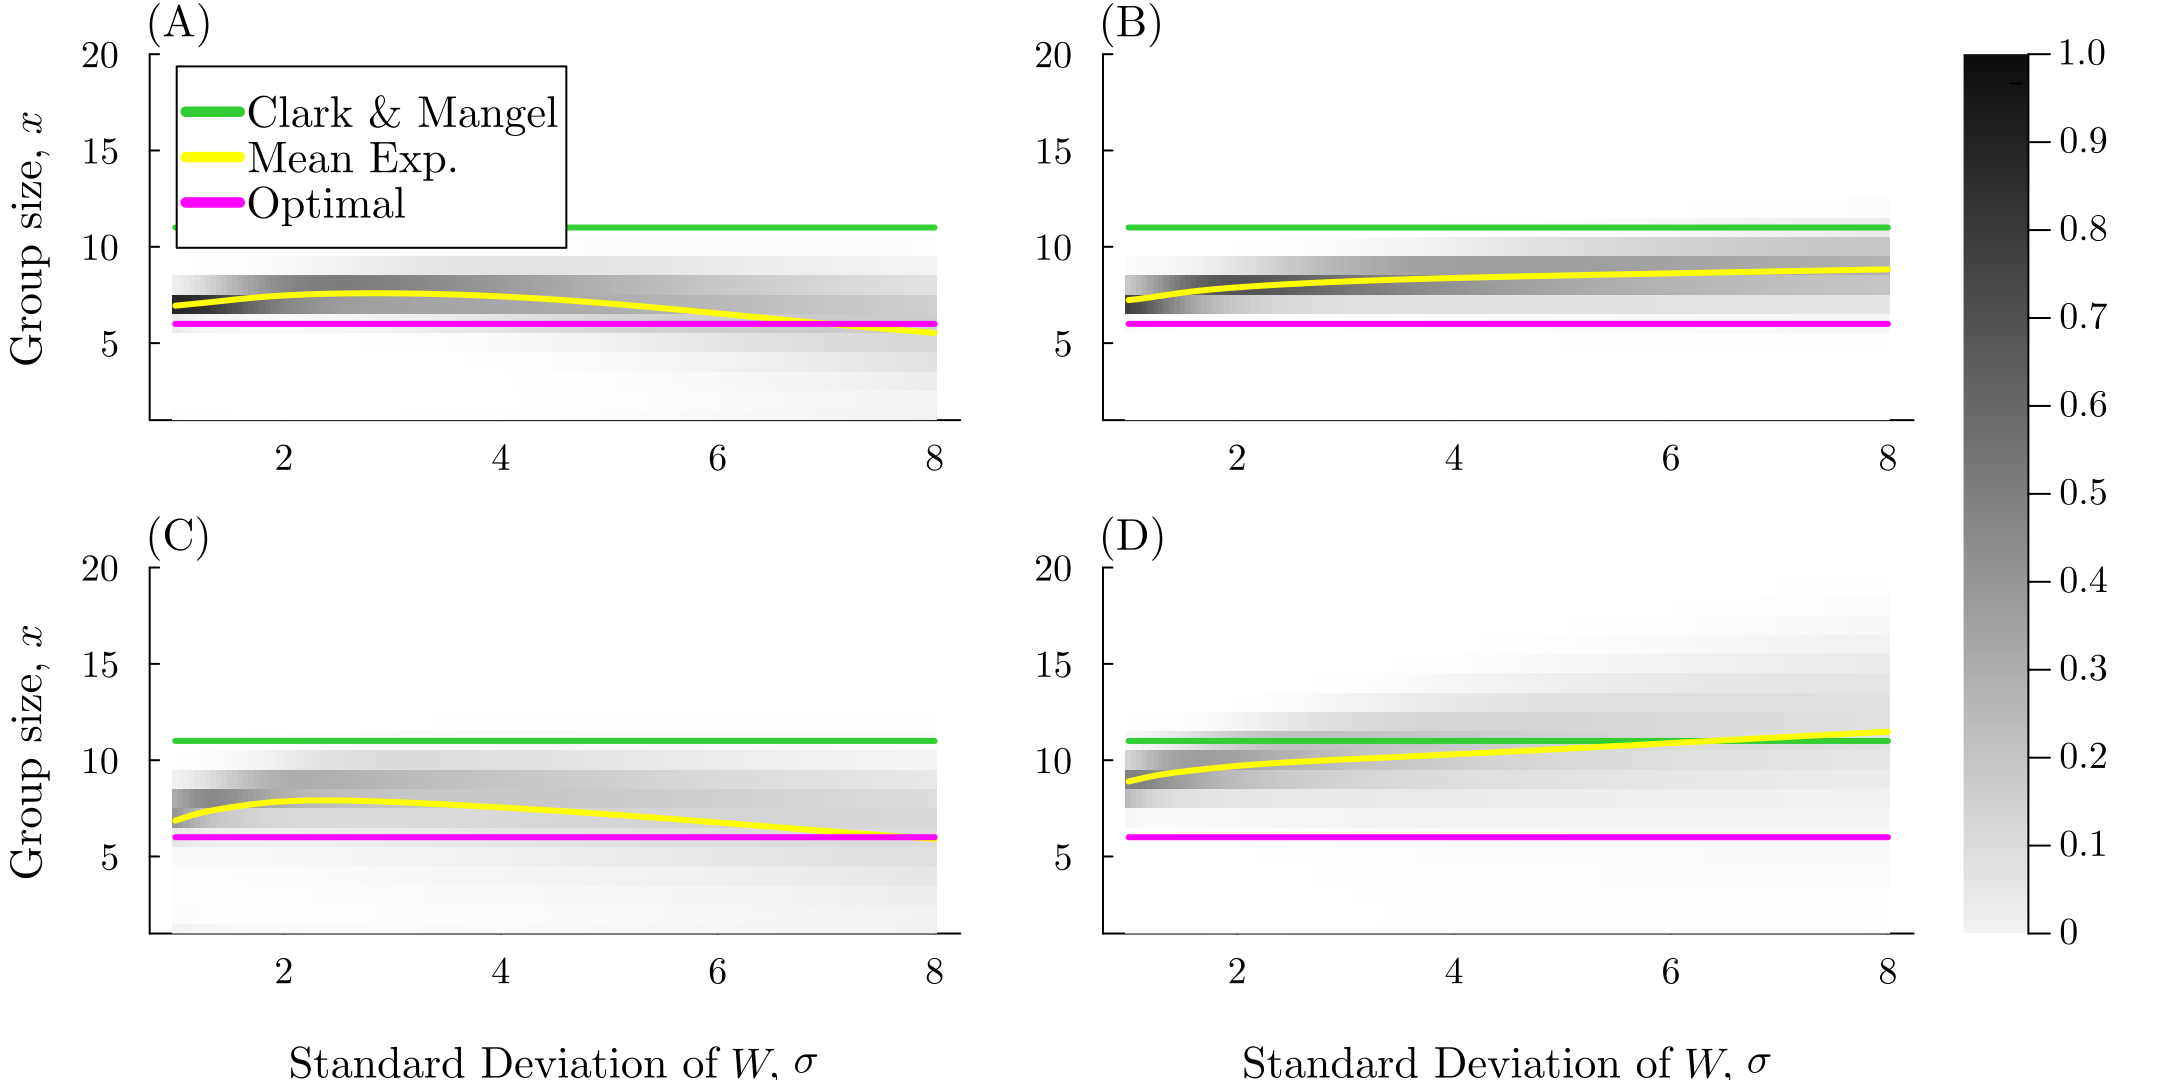

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


In [42]:
# Panels: (A) ℓ=φ=1 no births, (B) ℓ=φ=0.01 no births,
#         (C) ℓ=φ=1 with births, (D) ℓ=φ=0.01 with births
paramkey = :σ
paramvec = collect(1:0.05:8)

# scale_fun=identity because fun_W_gauss params need no dimensional rescaling
hm1, λ1 = make_hm_versus_param_solve_g(paramkey, paramvec, params_base;        W_fun=fun_W_gauss, scale_fun=identity)
hm2, λ2 = make_hm_versus_param_solve_g(paramkey, paramvec, params_supp;        W_fun=fun_W_gauss, scale_fun=identity)
hm3, λ3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births;      W_fun=fun_W_gauss, scale_fun=identity)
hm4, λ4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births_supp; W_fun=fun_W_gauss, scale_fun=identity)

for hm in [hm1, hm2, hm3, hm4]
    hm.subplots[1][:annotations] = []
end

clims = (0.0, 1.0)
p1 = plot(
    plot(hm1; legend=true, xlab=""),
    plot(hm2; legend=false, xlab="", ylab="", right_margin=5mm),
    plot(hm3; legend=false),
    plot(hm4; legend=false, ylab="");
    clims=clims, colorbar=false,
    title=["(A)" "(B)" "(C)" "(D)"], titlelocation=:left, titlefonthalign=:left
)
# p_cb: dummy heatmap used solely to render a shared colorbar on the right
p_cb = heatmap(fill(NaN, 2, 2); clims, c=cgrad(:grays, rev=true), colorbar=:right,
               framestyle=:none, ticks=false)
p_full = plot(p1, p_cb; layout=grid(1, 2, widths=[0.94, 0.06]),
             size=(1080, 540), bottom_margin=5mm, left_margin=5mm)
savefig(p_full, fig_path * "4heatmaps.pdf")
p_full

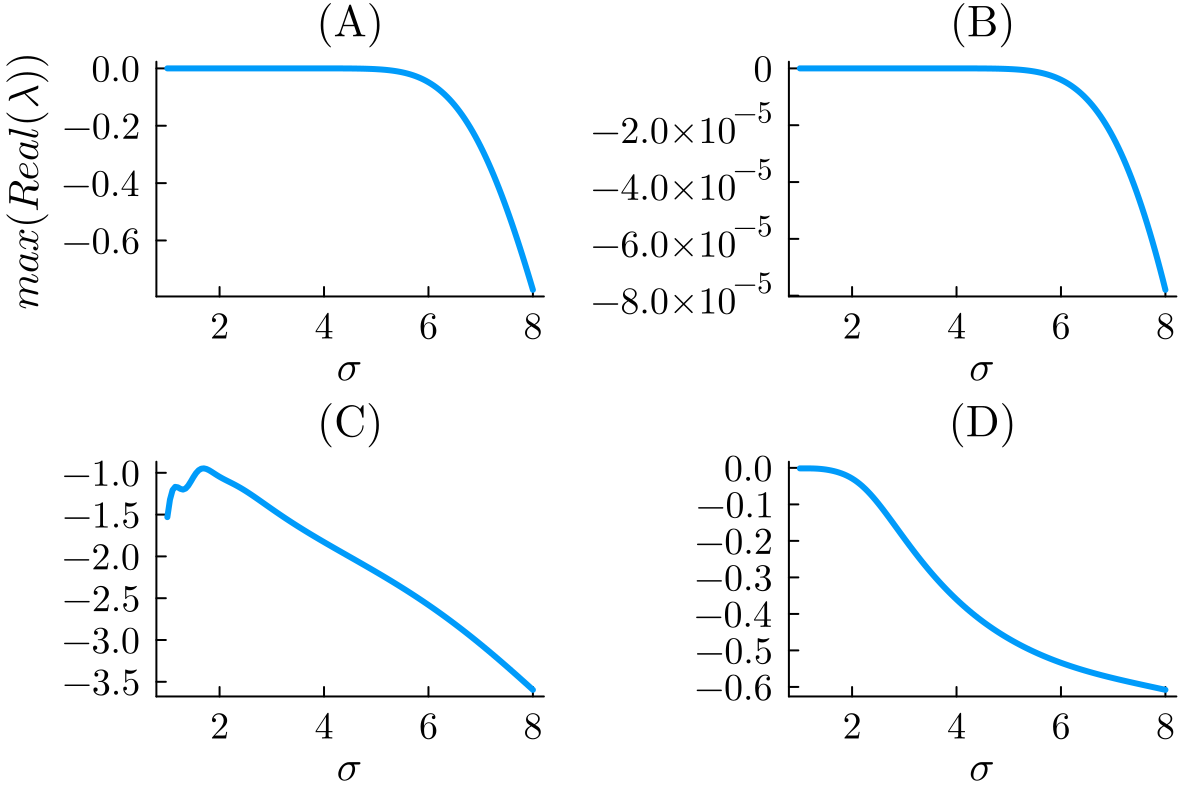

In [11]:
plot(
    plot(paramvec, λ1, ylabel=L"max(Real(\lambda))", title="(A)", xlabel=""),
    plot(paramvec, λ2, title="(B)", xlabel="", ylab=""),
    plot(paramvec, λ3, title="(C)"),
    plot(paramvec, λ4, title="(D)", ylab="");
    xlab=L"\sigma", legend=false, layout=(2,2)
)
# plots the maximum real part of the eigenvalues

### Check other starting points

In [46]:
g0 = zeros(x_max-1)
g0[1] = 11.0
g0[3] = (P - g0[1])/3

hm3, λ3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births;      
    W_fun=fun_W_gauss, scale_fun=identity, g0_births = g0)
hm4, λ4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births_supp; 
W_fun=fun_W_gauss, scale_fun=identity, g0_births = g0)

for hm in [hm3, hm4]
    hm.subplots[1][:annotations] = []
end

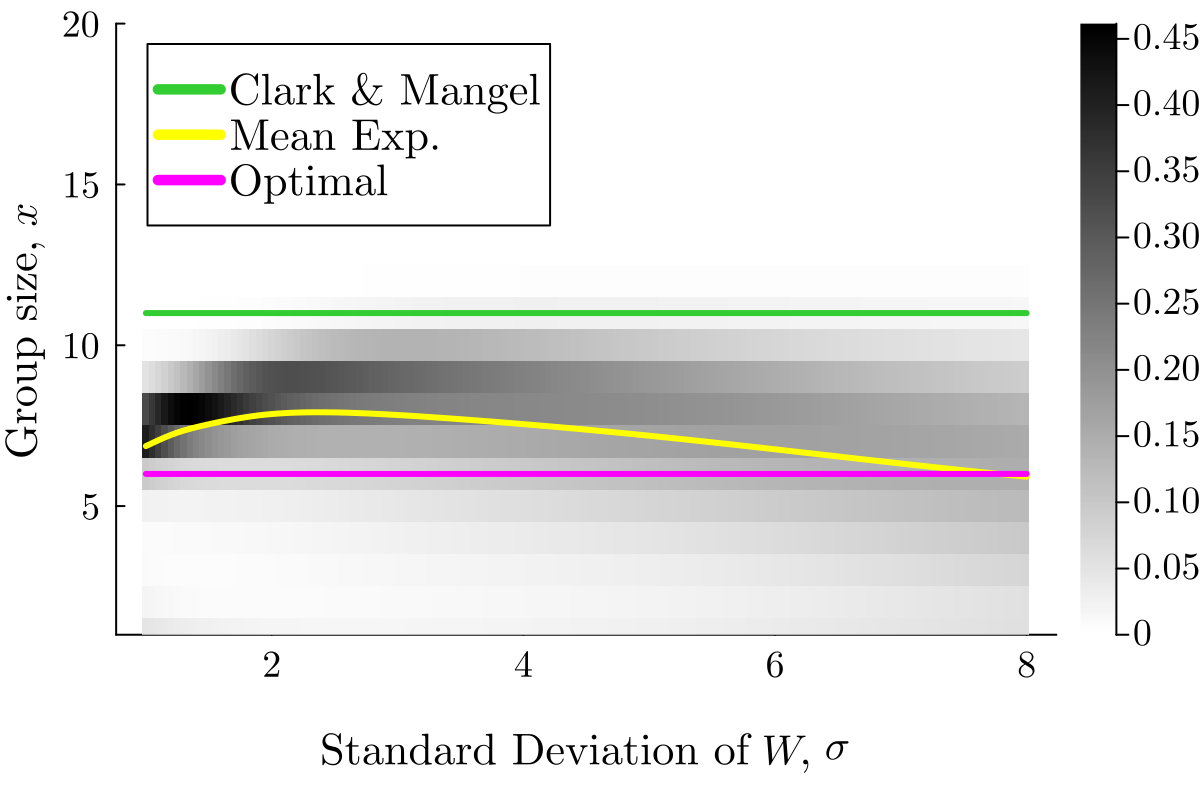

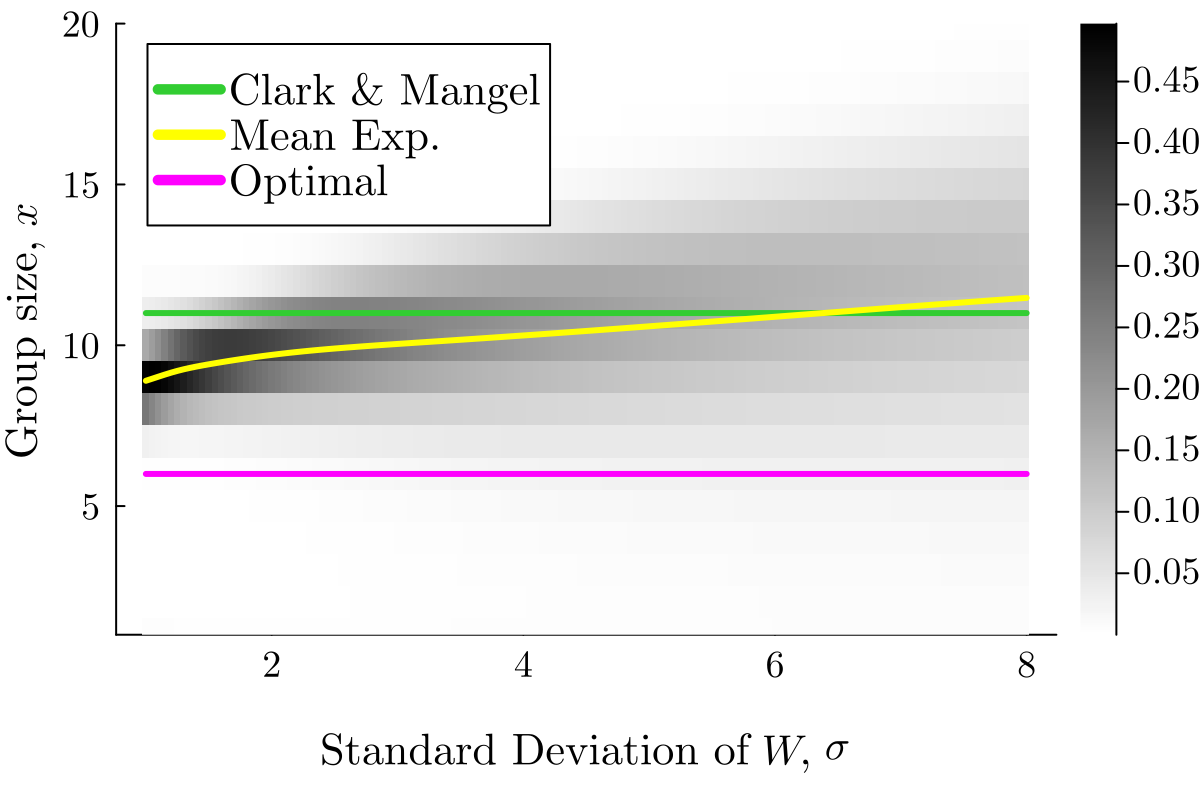

In [47]:
display(hm3)

display(hm4)

# Figure S1.3: Vary a

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


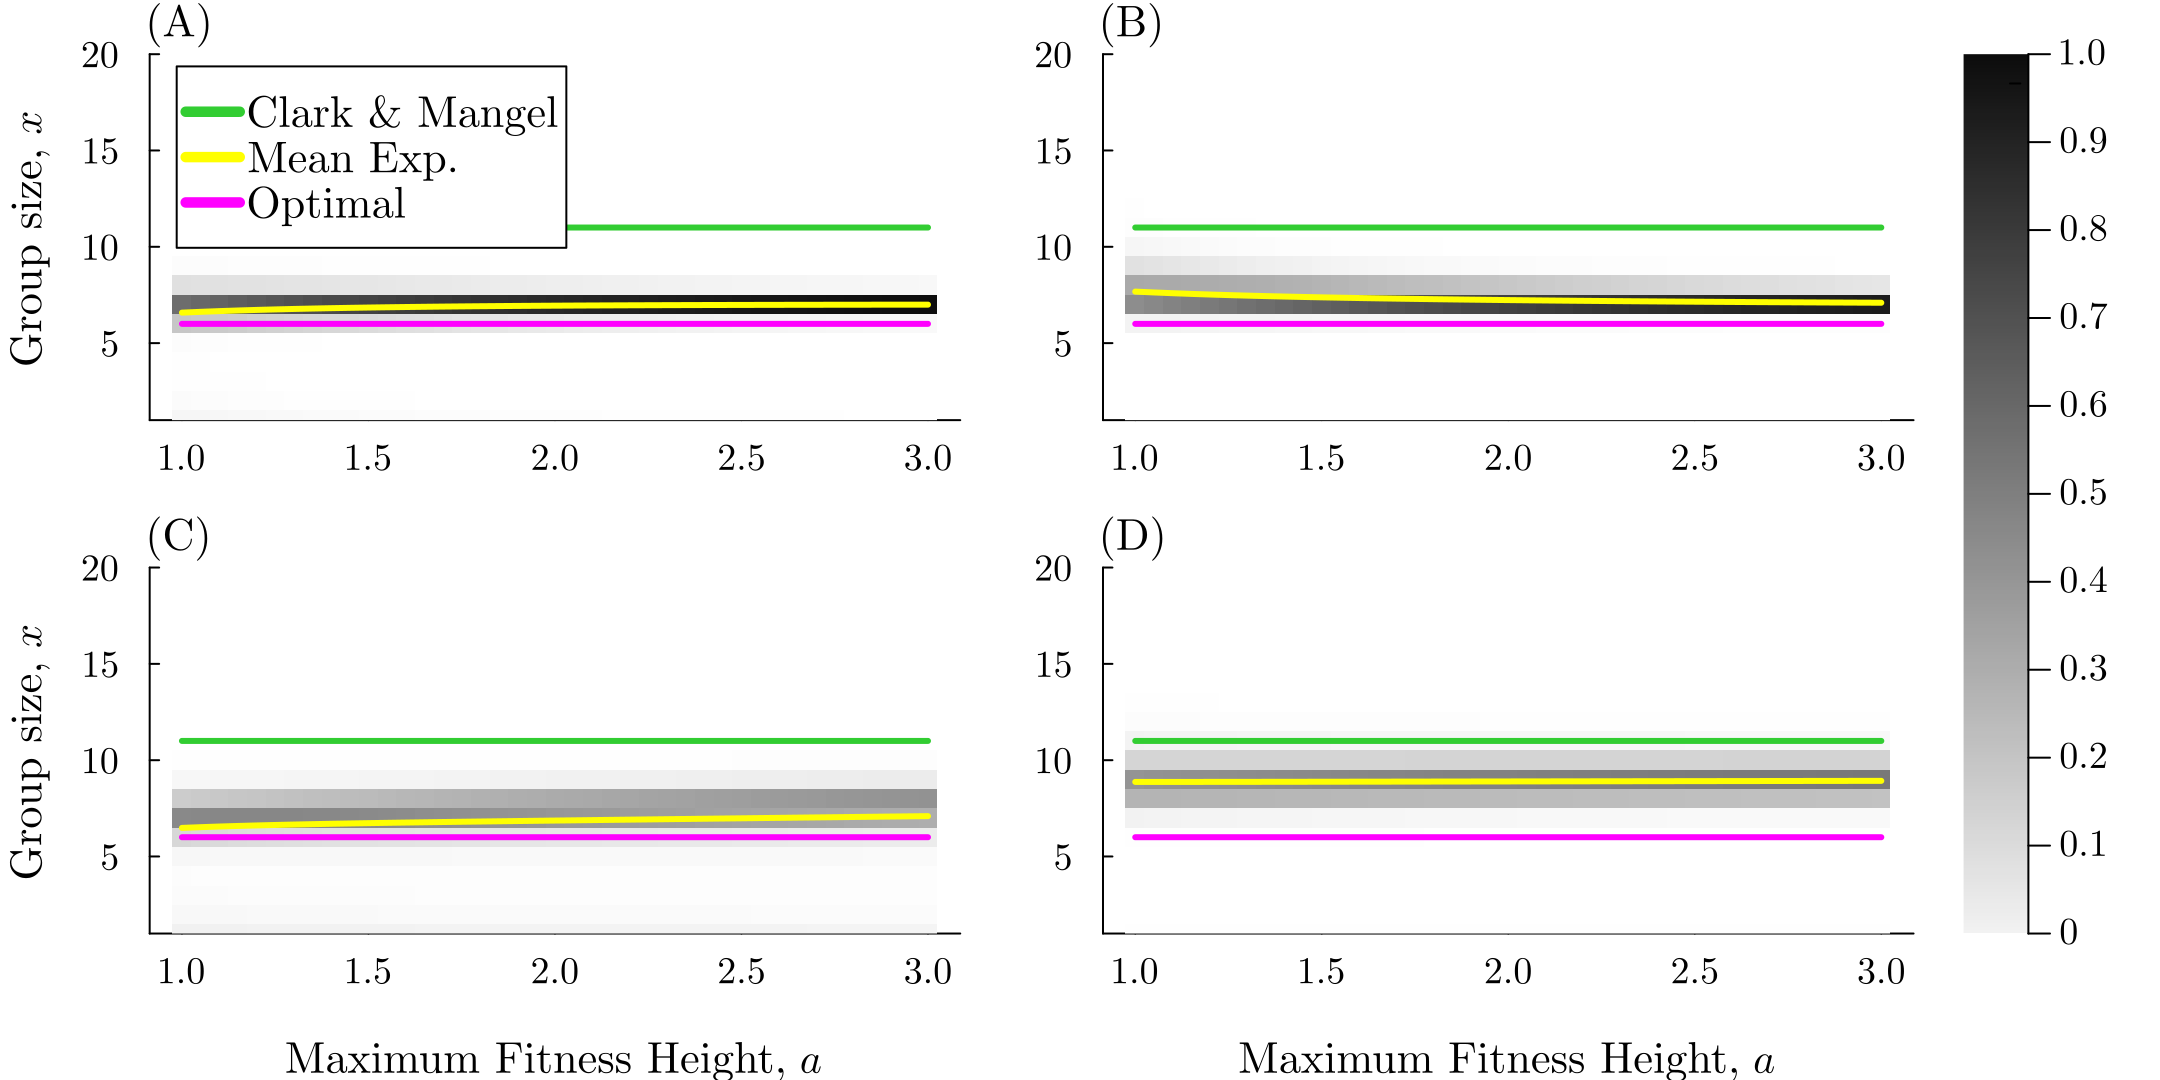

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


In [51]:
# Panels: (A) ℓ=φ=1 no births, (B) ℓ=φ=0.01 no births,
#         (C) ℓ=φ=1 with births, (D) ℓ=φ=0.01 with births
paramkey = :a
paramvec = collect(1:0.05:3)

hm1, λ1 = make_hm_versus_param_solve_g(paramkey, paramvec, params_base;        W_fun=fun_W_gauss, scale_fun=identity)
hm2, λ2 = make_hm_versus_param_solve_g(paramkey, paramvec, params_supp;        W_fun=fun_W_gauss, scale_fun=identity)
hm3, λ3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births;      W_fun=fun_W_gauss, scale_fun=identity)
hm4, λ4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births_supp; W_fun=fun_W_gauss, scale_fun=identity)

for hm in [hm1, hm2, hm3, hm4]
    hm.subplots[1][:annotations] = []
end

clims = (0.0, 1.0)
p1 = plot(
    plot(hm1; legend=true, xlab=""),
    plot(hm2; legend=false, xlab="", ylab="", right_margin=5mm),
    plot(hm3; legend=false),
    plot(hm4; legend=false, ylab="");
    clims=clims, colorbar=false,
    title=["(A)" "(B)" "(C)" "(D)"], titlelocation=:left, titlefonthalign=:left
)
p_cb = heatmap(fill(NaN, 2, 2); clims, c=cgrad(:grays, rev=true), colorbar=:right,
               framestyle=:none, ticks=false)
p_full = plot(p1, p_cb; layout=grid(1, 2, widths=[0.94, 0.06]),
             size=(1080, 540), bottom_margin=5mm, left_margin=5mm)
savefig(p_full, fig_path * "4heatmaps_a.pdf")
p_full

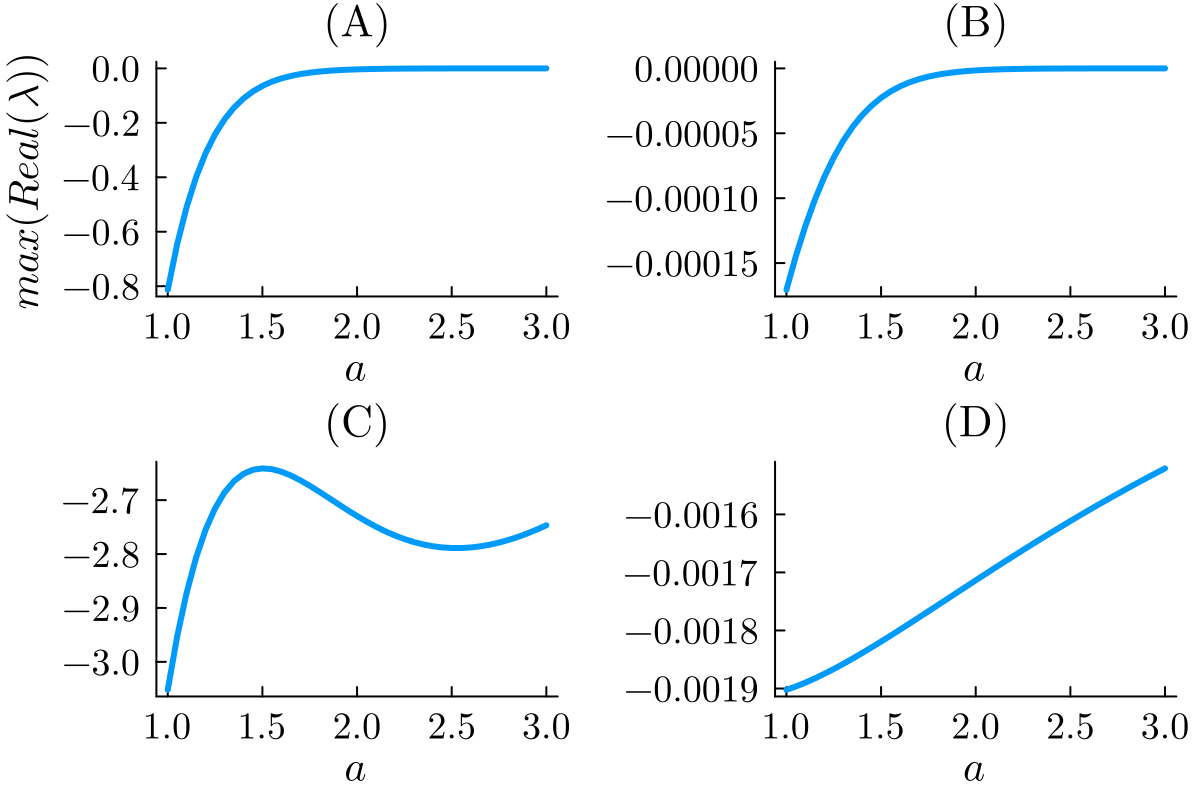

In [ ]:
plot(
    plot(paramvec, λ1, ylabel=L"max(Real(\lambda))", title="(A)", xlabel=""),
    plot(paramvec, λ2, title="(B)", xlabel="", ylab=""),
    plot(paramvec, λ3, title="(C)"),
    plot(paramvec, λ4, title="(D)", ylab="");
    xlab=L"a", legend=false, layout=(2,2)
)

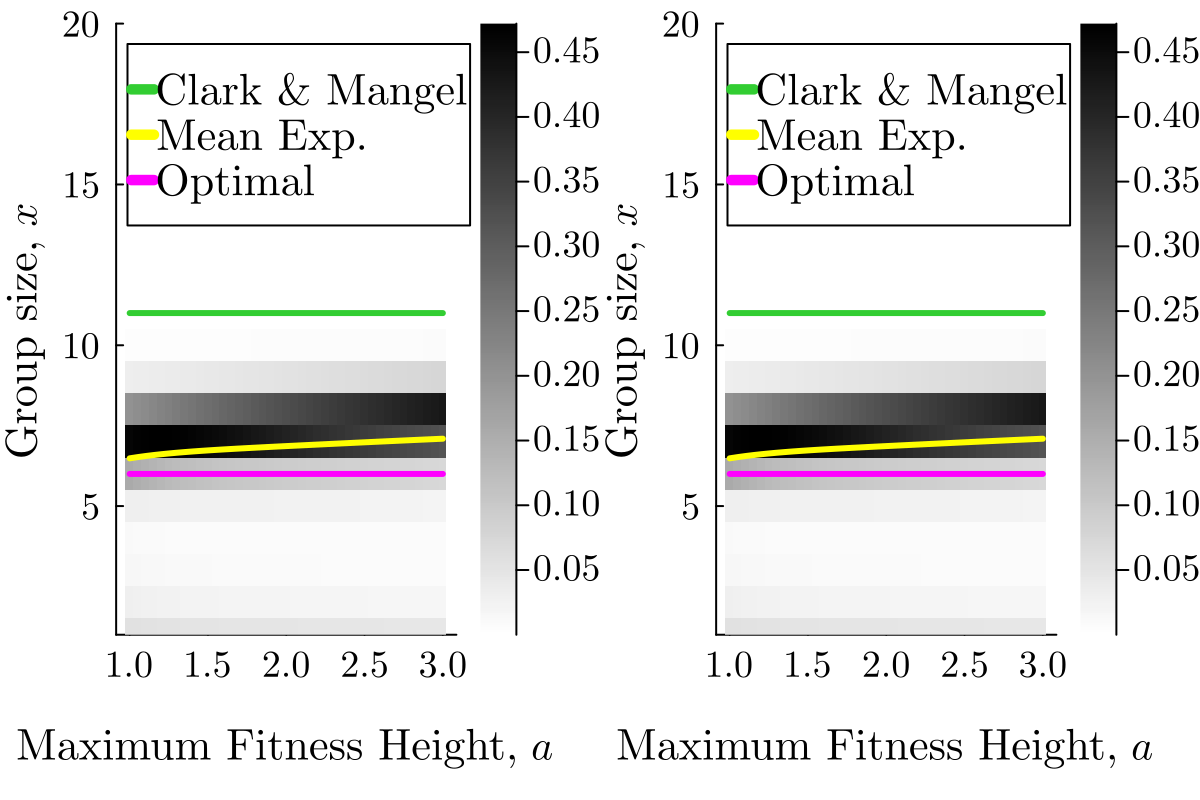

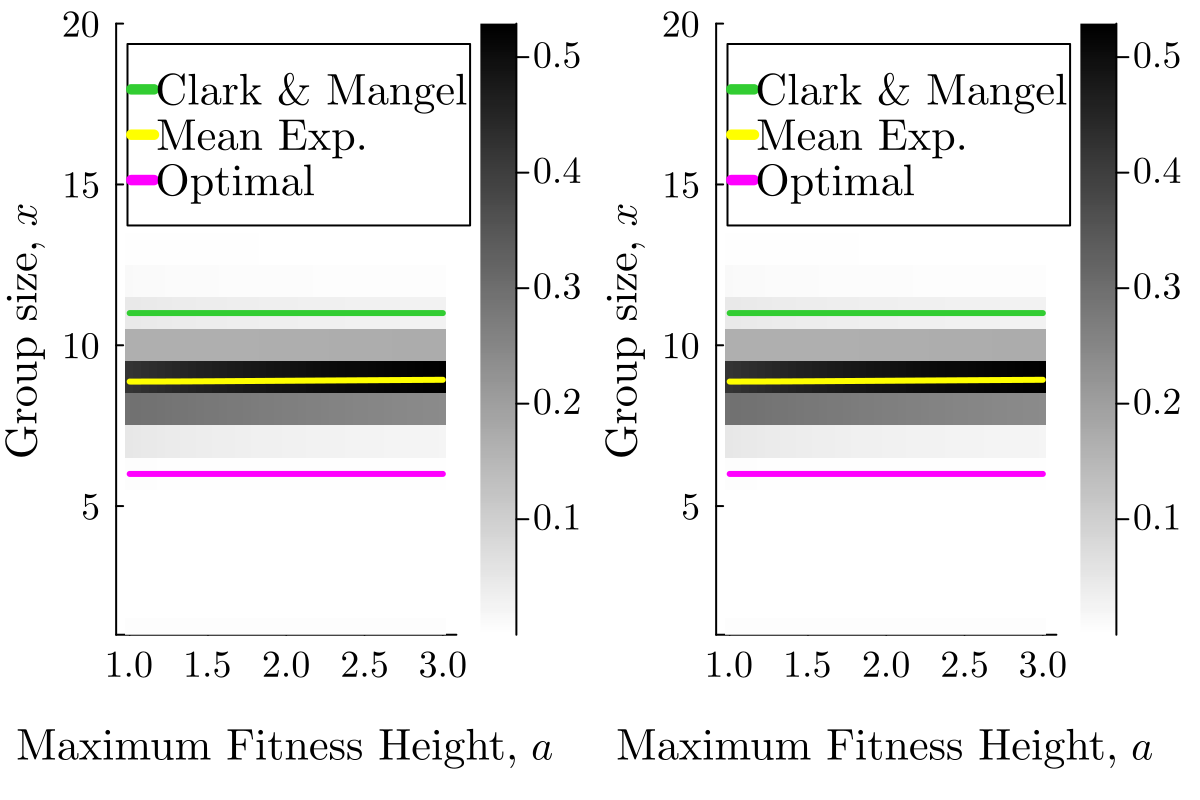

In [53]:
g0 = zeros(x_max-1)
g0[1] = 11.0
g0[3] = (P - g0[1])/3

hm3a, λ3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births;      
    W_fun=fun_W_gauss, scale_fun=identity, g0_births = g0)
hm4a, λ4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births_supp; 
W_fun=fun_W_gauss, scale_fun=identity, g0_births = g0)

for hm in [hm3a, hm4a]
    hm.subplots[1][:annotations] = []
end
p3 = plot(hm3, hm3a)

p4 = plot(hm4, hm4a)
display(p3)
display(p4)

# Figure S1.4: Vary x0

In [ ]:
# Panels: (A) ℓ=φ=1 no births, (B) ℓ=φ=0.01 no births,
#         (C) ℓ=φ=1 with births, (D) ℓ=φ=0.01 with births
paramkey = :x0
paramvec = collect(1:0.05:6)

hm1, λ1 = make_hm_versus_param_solve_g(paramkey, paramvec, params_base;        W_fun=fun_W_gauss, scale_fun=identity)
hm2, λ2 = make_hm_versus_param_solve_g(paramkey, paramvec, params_supp;        W_fun=fun_W_gauss, scale_fun=identity)
hm3, λ3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births;      W_fun=fun_W_gauss, scale_fun=identity)
hm4, λ4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births_supp; W_fun=fun_W_gauss, scale_fun=identity)

for hm in [hm1, hm2, hm3, hm4]
    hm.subplots[1][:annotations] = []
end

clims = (0.0, 1.0)
p1 = plot(
    plot(hm1; legend=true, xlab=""),
    plot(hm2; legend=false, xlab="", ylab="", right_margin=5mm),
    plot(hm3; legend=false),
    plot(hm4; legend=false, ylab="");
    clims=clims, colorbar=false,
    title=["(A)" "(B)" "(C)" "(D)"], titlelocation=:left, titlefonthalign=:left,
    ylims=(0, 15)  # cap y-axis: x0 reaches at most 6, so x_max=20 wastes space
)
p_cb = heatmap(fill(NaN, 2, 2); clims, c=cgrad(:grays, rev=true), colorbar=:right,
               framestyle=:none, ticks=false)
p_full = plot(p1, p_cb; layout=grid(1, 2, widths=[0.94, 0.06]),
             size=(1080, 540), bottom_margin=5mm, left_margin=5mm)
savefig(p_full, fig_path * "4heatmaps_x0.pdf")
p_full

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


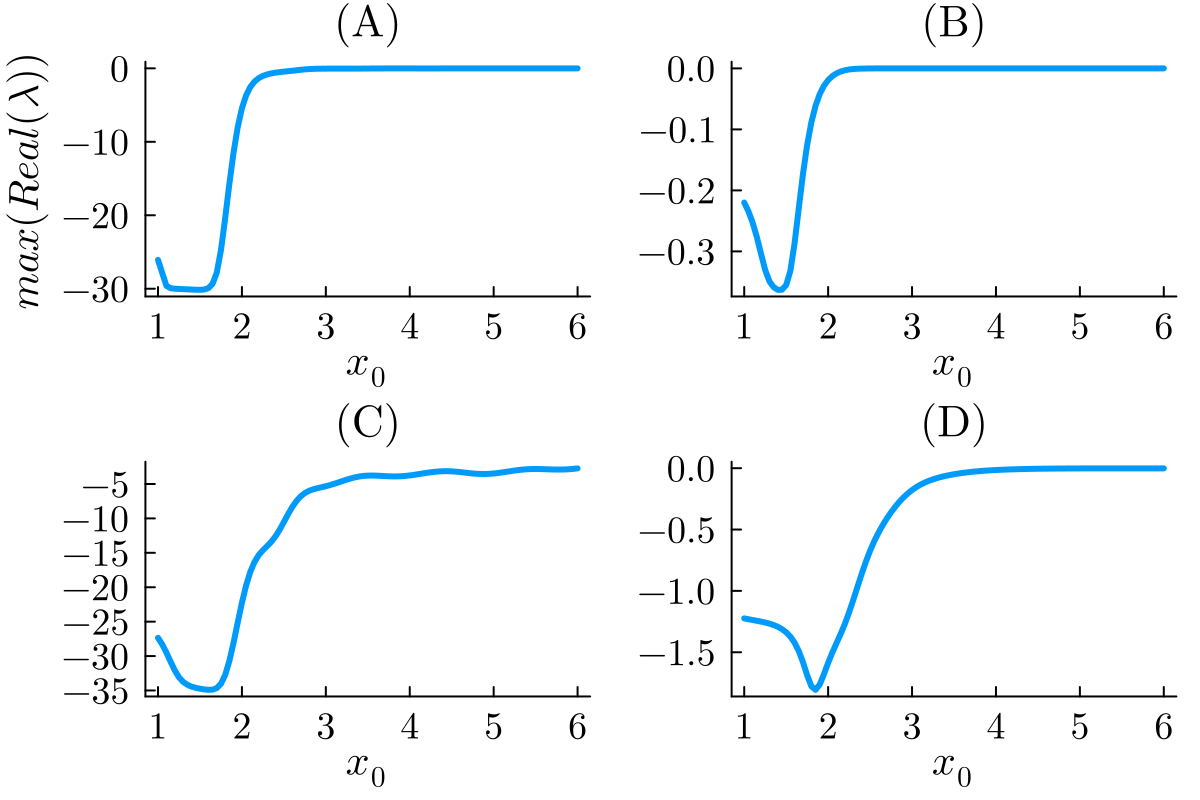

In [20]:
# leading eigenvalue of Jacobian at equilibrium for each panel
plot(
    plot(paramvec, λ1, ylabel=L"max(Real(\lambda))", title="(A)", xlabel=""),
    plot(paramvec, λ2, title="(B)", xlabel="", ylab=""),
    plot(paramvec, λ3, title="(C)"),
    plot(paramvec, λ4, title="(D)", ylab="");
    xlab=L"x_0", legend=false, layout=(2,2)
)

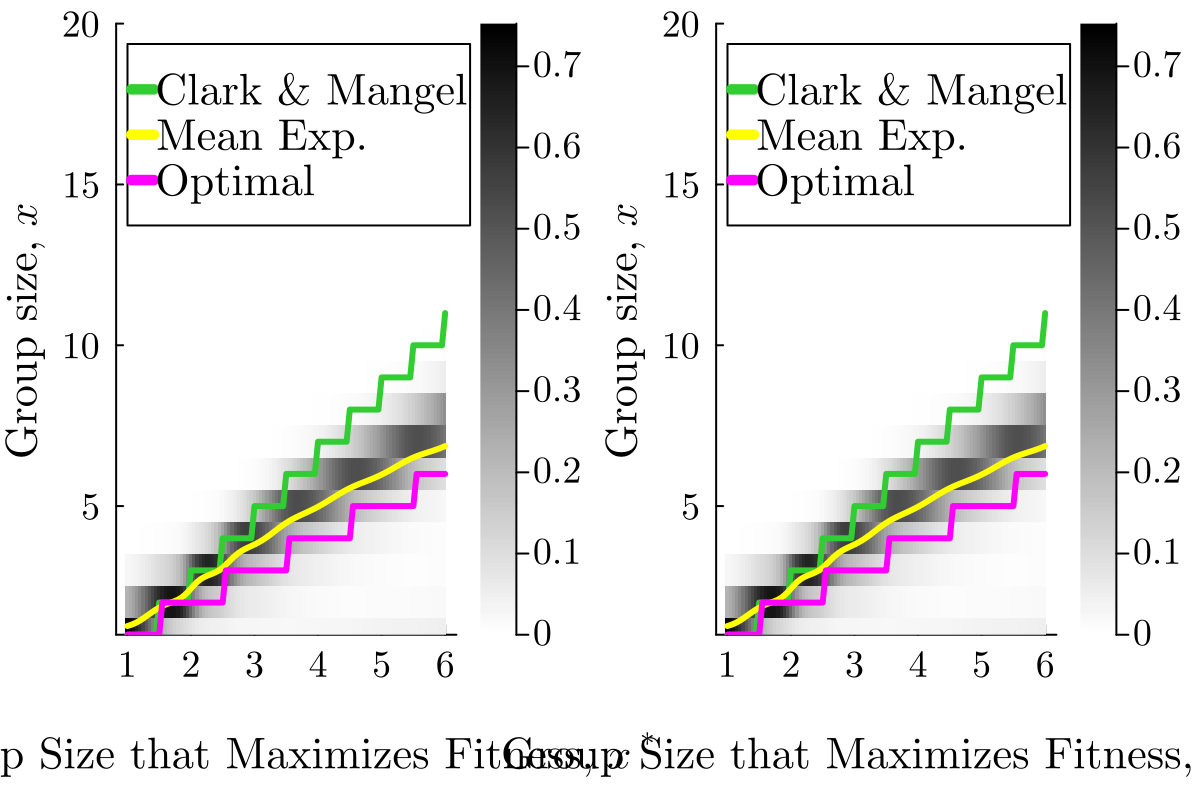

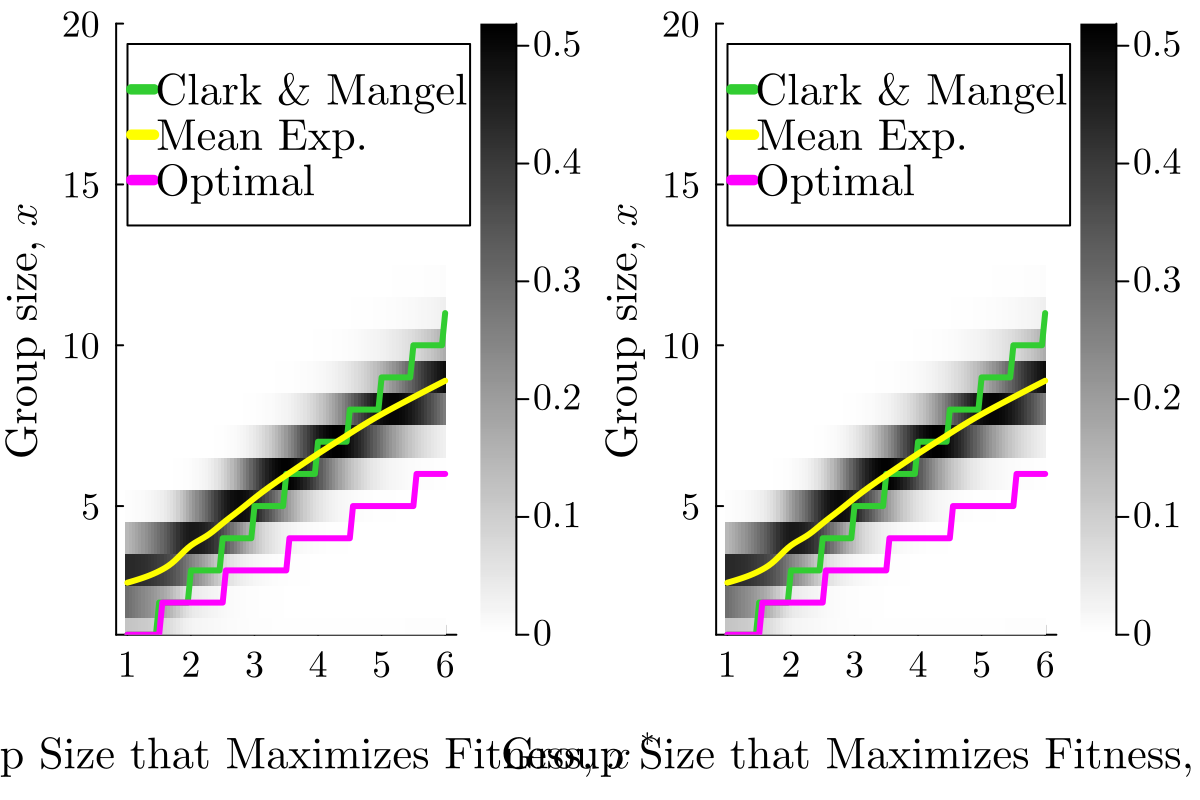

In [55]:
g0 = zeros(x_max-1)
g0[1] = 11.0
g0[3] = (P - g0[1])/3

hm3a, λ3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births;      
    W_fun=fun_W_gauss, scale_fun=identity, g0_births = g0)
hm4a, λ4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births_supp; 
W_fun=fun_W_gauss, scale_fun=identity, g0_births = g0)

for hm in [hm3a, hm4a]
    hm.subplots[1][:annotations] = []
end
p3 = plot(hm3, hm3a)

p4 = plot(hm4, hm4a)
display(p3)
display(p4)

# Some heatmaps of modulating fusing/pairing

In [29]:
using DifferentialEquations
using LinearAlgebra # so I can do norm
function plot_hm_modulate_leave_births(
    g0, params_base, ODE_fun_handle; 
    n = 10, t_f = 50000.0, clims = Nothing,
    leave_start = 0.01, fuse_start = 0.01)

    #=
    Heatmap of final g for leave-param vs fuse-param
    ODE_fun_handle must be in place. eg: fun_dg_simpleW!, fun_dg_simpleW_births_constantP!
    uses fun_W_gauss
    =#
    # --- grids (adjust resolution as you like) ---
    leave_grid = range(leave_start, 1.0; length=n)   # x-axis
    fuse_grid  = range(fuse_start, 1.0; length=n)   # y-axis

    @unpack x_max = params_base
    params = deepcopy(params_base)

    P = x_max

    # result matrix: rows = fuse_grid (y), cols = leave_grid (x)
    meanx_Z = Array{Float64}(undef, length(fuse_grid), length(leave_grid))

    # (optional) track equilibrium if you want a mask/contours later
    reached_eq = falses(size(meanx_Z))

    # find mangel and clark prediction:
    W = fun_W_gauss(1:15,params_base)
    x_mc = findlast(W .>= W[1])

    for (ix, leave_val) in enumerate(leave_grid)
        for (iy, fuse_val) in enumerate(fuse_grid)
            # update parameters
            params[:leave_param] = leave_val;
            params[:fuse_param]  = fuse_val;
            # solve system
            prob = ODEProblem(ODE_fun_handle, g0, (0.0, t_f), 
                    NamedTuple(params); 
                    save_everystep=false) #remake(base_prob; p = NamedTuple(params), u0 = g0)
            sol  = solve(prob)

            g_final = sol.u[end]
            meanx_Z[iy, ix] = get_meanx(g_final, x_max)

            # equilibrium check (same criterion you used before)
            dg = zeros(x_max)
            ODE_fun_handle(dg, g_final, NamedTuple(params), 500.0)
            reached_eq[iy, ix] = norm(dg,Inf) < 1e-9
            if norm(dg,Inf) >= 1e-9
                normval = round(norm(dg,Inf),sigdigits=2)
                print("Norm(dg) = $normval. fuse_val = $fuse_val, leave_val = $leave_val \n")
            end
        
        end
    end
    if clims == Nothing
        clims = (minimum(meanx_Z), maximum(meanx_Z))
    end
    # --- plot ---
    hm2 = heatmap(
        leave_grid,                # x
        fuse_grid,                 # y
        meanx_Z,                   # Z has size (length(y), length(x))
        xlabel = L"$l$, Leaving Parameter",
        ylabel = L"$\phi$, Fusing Parameter",
        c = cgrad(:viridis),     # darker = higher
        clims = clims,#(minimum(meanx_Z), maximum(meanx_Z)),
        colorbar_ticks = (ceil(Int, minimum(meanx_Z)):1:floor(Int, maximum(meanx_Z))),
        interpolate=false,
        xlims = [0,1],
        ylims = [0,1]
    )

    return hm2, reached_eq, x_mc
end

plot_hm_modulate_leave_births (generic function with 2 methods)

In [30]:
params_base = Dict(
    :a => 2.0,
    :σ => 1,
    :x0 => 5,
    :Tg => .01,
    :d => 2,
    :x_max => 15,
    :leave_param => 1.0,
    :fuse_param => 1.0
)
P = 15.0

15.0

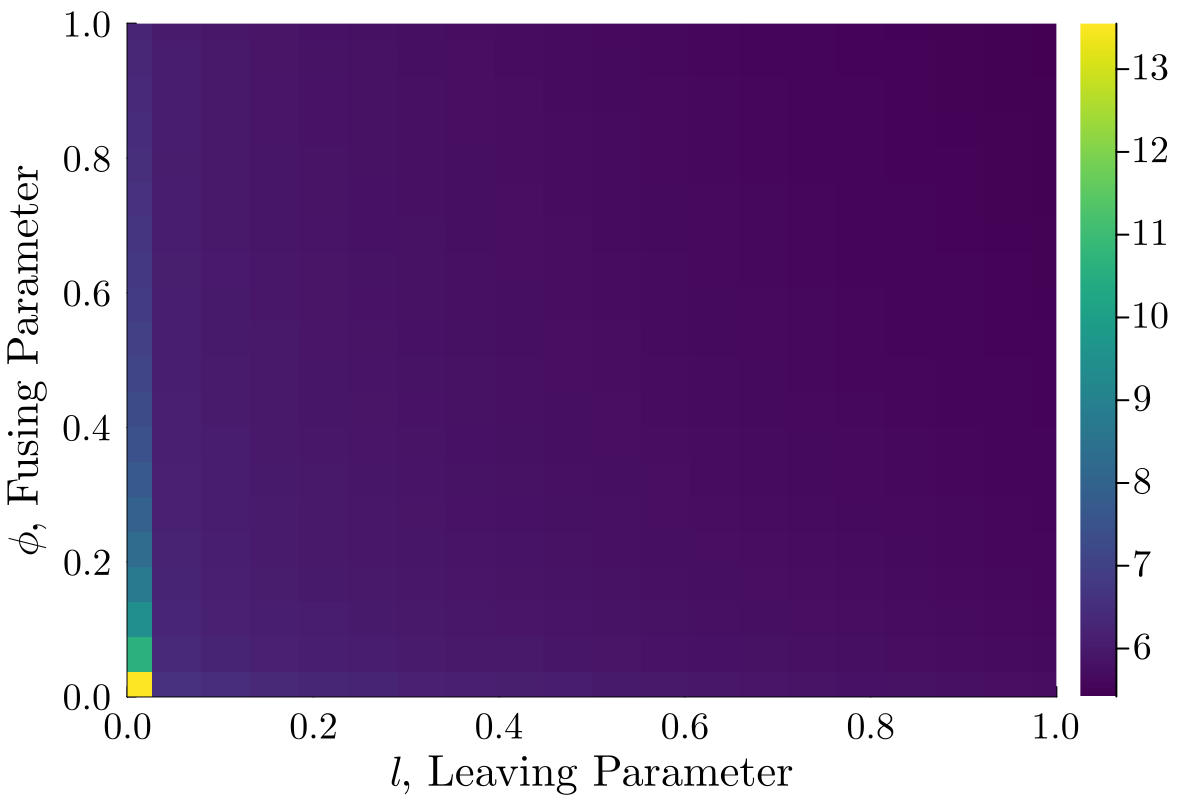

In [33]:
g0 = zeros(params_base[:x_max])
g0[1] = 8.0
g0[7] = (P - g0[1])/7

ODE_fun_handle = fun_dg_simpleW!
hm2, reached_eq, x_mc = plot_hm_modulate_leave_births(g0, params_base, ODE_fun_handle; 
    n = 20, t_f = 50000.0, clims = Nothing, leave_start = 0.0)

hm2

In [34]:
reached_eq # remember first rows are actually bottom of figure above

20×20 BitMatrix:
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1

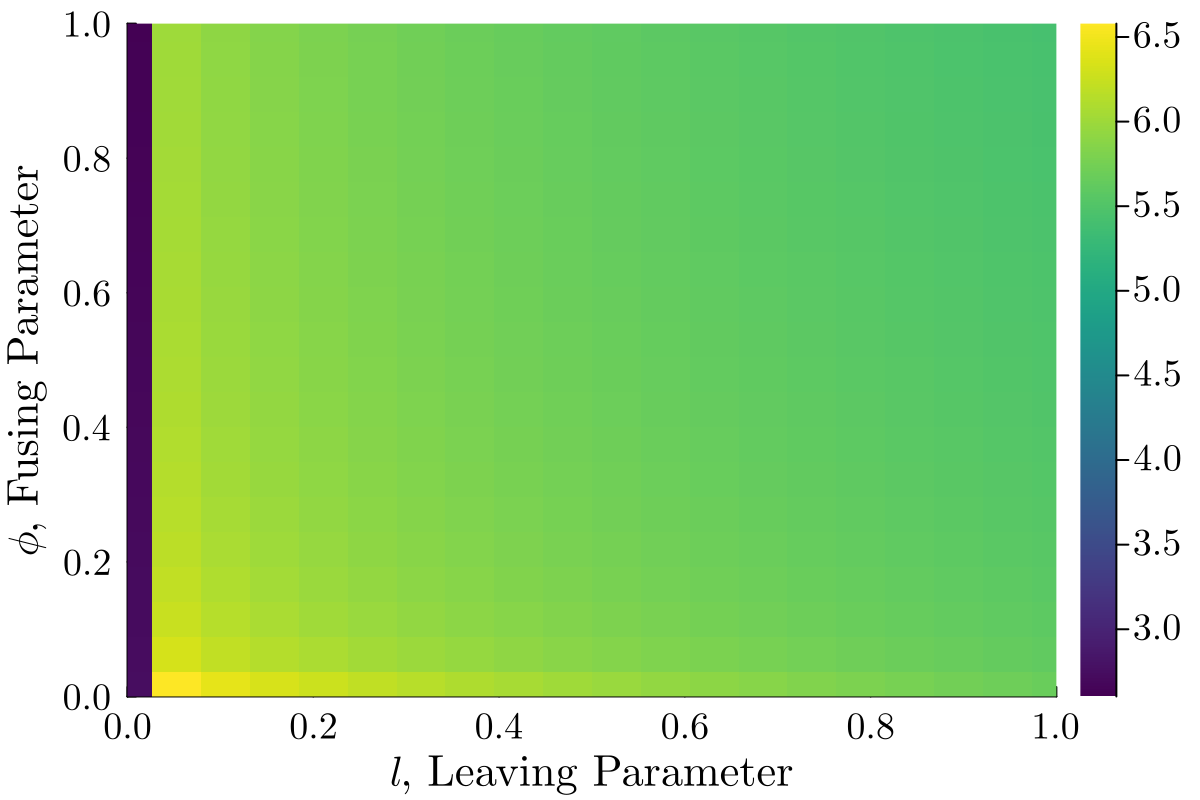

In [36]:
g0 = zeros(params_base[:x_max])
g0[1] = 3.0
g0[2] = 6.0

ODE_fun_handle = fun_dg_simpleW!
hm2, reached_eq, x_mc = plot_hm_modulate_leave_births(g0, params_base, ODE_fun_handle; 
    n = 20, t_f = 20000.0, clims = Nothing, leave_start = 0.0)

#savefig(hm2, fig_path*"hm_modulate_l_phi_init2.pdf")
hm2

In [37]:
reached_eq

20×20 BitMatrix:
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1